In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

# Stats / TS
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, classification_report
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

### Data cleaning

In [ ]:
df=pd.read_excel('/content/ecom_transactions.xlsx')
df.head()

,transaction_id,zip_code,country_code,state_name,city_name,delivery_type,sales_zone,client_segment,client_id,order_ts,dispatch_ts,item_id,item_description,units_count,total_sum,profit,discount
0,T01936,85023.0,USA,Arizona,Phoenix,Standard Class,West,Consumer,C0568,2021-07-17,2021-07-22,P00856,"Furniture_Tables_Chromcraft 48"" x 96"" Racetrac...",5,801.600,-448.8960,0.5
1,T00178,98198.0,USA,Washington,Des Moines,Second Class,West,Consumer,C1308,2018-09-19,2018-09-21,P00349,Technology_Phones_Nortel Meridian M3904 Profes...,2,246.384,27.7182,0.2
2,T04512,NaN,USA,Illinois,Quincy,Standard Class,Central,Consumer,C0475,2019-09-30,2019-10-04,P01391,Office Supplies_Binders_Accohide Poly Flexible...,4,2.992,-4.4880,0.8
3,T01059,78041.0,USA,Texas,Laredo,Standard Class,Central,Consumer,C0445,2020-10-12,2020-10-18,P00584,"Furniture_Furnishings_Tenex ""The Solids"" Textu...",5,139.920,-150.4140,0.6
4,T04032,92037.0,USA,California,San Diego,Standard Class,West,CONSUMER,C0462,2020-02-04,2020-02-09,P00608,Office Supplies_Labels_Avery 508,3,14.730,7.2177,0.0


In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nSummary:\n", df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10486 non-null  object        
 1   zip_code          10174 non-null  float64       
 2   country_code      10486 non-null  object        
 3   state_name        10486 non-null  object        
 4   city_name         10486 non-null  object        
 5   delivery_type     10173 non-null  object        
 6   sales_zone        10486 non-null  object        
 7   client_segment    10486 non-null  object        
 8   client_id         10486 non-null  object        
 9   order_ts          10486 non-null  datetime64[ns]
 10  dispatch_ts       10276 non-null  datetime64[ns]
 11  item_id           10486 non-null  object        
 12  item_description  10486 non-null  object        
 13  units_count       10486 non-null  int64         
 14  total_sum         1017

**Identify & handle missing values**

In [ ]:
missing = df.isna().sum()
missing[missing > 0]


,0
zip_code,312
delivery_type,313
dispatch_ts,210
total_sum,315
profit,317
discount,310


In [ ]:
# Числовые — медиана
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Категориальные — мода
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df["dispatch_ts"] = pd.to_datetime(df["dispatch_ts"], errors="coerce")


**Detect & treat outliers (IQR method)**

In [ ]:
# числовые столбцы
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

outliers_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_summary[col] = outliers.shape[0]

outliers_summary


{'zip_code': 0,
 'units_count': 174,
 'total_sum': 1255,
 'profit': 2105,
 'discount': 965}

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


**Normalize inconsistent categorical variable**

In [ ]:
for col in cat_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
    )


**Fix incorrect data types & remove duplicates**

In [ ]:
# datetime
if "dispatch_ts" in df.columns:
    df["dispatch_ts"] = pd.to_datetime(df["dispatch_ts"], errors="coerce")

# integer
df["units_count"] = df["units_count"].astype(int)


In [ ]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()


Duplicates: 0


**Identify & correct logical errors**

In [ ]:
# отрицательные значения
df.loc[df["units_count"] < 0, "units_count"] = np.nan
df.loc[df["total_sum"] < 0, "total_sum"] = np.nan
df.loc[df["discount"] < 0, "discount"] = 0
# profit не может быть больше total_sum
df.loc[df["profit"] > df["total_sum"], "profit"] = df["total_sum"]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [ ]:
(df["profit"] < 0).mean()
df.loc[df["profit"] < 0, ["total_sum", "discount", "profit"]].head()


,total_sum,discount,profit
0,497.35125,0.5,-37.229837
2,2.99200,0.5,-4.488000
3,139.92000,0.5,-37.229837
7,230.37600,0.2,-37.229837
9,497.35125,0.5,-37.229837


In [ ]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10486 non-null  object        
 1   zip_code          10486 non-null  float64       
 2   country_code      10486 non-null  object        
 3   state_name        10486 non-null  object        
 4   city_name         10486 non-null  object        
 5   delivery_type     10486 non-null  object        
 6   sales_zone        10486 non-null  object        
 7   client_segment    10486 non-null  object        
 8   client_id         10486 non-null  object        
 9   order_ts          10486 non-null  datetime64[ns]
 10  dispatch_ts       10276 non-null  datetime64[ns]
 11  item_id           10486 non-null  object        
 12  item_description  10486 non-null  object        
 13  units_count       10486 non-null  float64       
 14  total_sum         1048

(10486, 17)

**CLIENT DATA**

In [ ]:
cl=pd.read_excel('/content/ecom_clients.xlsx')
cl.head()

,client_id,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,C0395,43,No,Travel_Frequently,313,Research & Development,21.0,3.0,Medical,1,...,1,80,1,8,1,3,3,2,1,2
1,C0840,35,No,Travel_Rarely,982,Research & Development,1.0,4.0,Medical,1,...,2,80,1,10,2,3,8,0,1,7
2,C1230,24,No,Travel_Rarely,506,Research & Development,29.0,1.0,Medical,1,...,2,80,3,6,2,4,6,2,1,2
3,C0507,29,No,Travel_Rarely,1176,Sales,3.0,2.0,Medical,1,...,1,80,1,6,5,2,6,0,1,2
4,C0853,19,No,Travel_Rarely,645,Research & Development,9.0,2.0,Life Sciences,1,...,3,80,0,1,4,3,1,1,0,0


In [ ]:
print(cl.info())
print(cl.describe())
cl.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 1495 non-null   object 
 1   Age                       1495 non-null   int64  
 2   Attrition                 1495 non-null   object 
 3   BusinessTravel            1495 non-null   object 
 4   DailyRate                 1495 non-null   int64  
 5   Department                1495 non-null   object 
 6   DistanceFromHome          1377 non-null   float64
 7   Education                 1376 non-null   float64
 8   EducationField            1495 non-null   object 
 9   EmployeeCount             1495 non-null   int64  
 10  EmployeeNumber            1495 non-null   int64  
 11  EnvironmentSatisfaction   1495 non-null   int64  
 12  Gender                    1495 non-null   object 
 13  HourlyRate                1495 non-null   int64  
 14  JobInvol

(1495, 36)

In [ ]:
missing = cl.isna().sum()
missing[missing > 0]


,0
DistanceFromHome,118
Education,119
JobSatisfaction,119
MonthlyIncome,118


In [ ]:
num_cols = cl.select_dtypes(include=["int64", "float64"]).columns
cat_cols = cl.select_dtypes(include=["object"]).columns
for col in num_cols:
    cl[col] = cl[col].fillna(cl[col].median())

for col in cat_cols:
    cl[col] = cl[col].fillna(cl[col].mode()[0])


In [ ]:
num_cols = cl.select_dtypes(include=["int64", "float64"]).columns

outliers_summary = {}

for col in num_cols:
    Q1 = cl[col].quantile(0.25)
    Q3 = cl[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cl[(cl[col] < lower) | (cl[col] > upper)]
    outliers_summary[col] = outliers.shape[0]

outliers_summary


{'Age': 22,
 'DailyRate': 0,
 'DistanceFromHome': 46,
 'Education': 0,
 'EmployeeCount': 0,
 'EmployeeNumber': 0,
 'EnvironmentSatisfaction': 0,
 'HourlyRate': 0,
 'JobInvolvement': 0,
 'JobLevel': 0,
 'JobSatisfaction': 0,
 'MonthlyIncome': 126,
 'MonthlyRate': 0,
 'NumCompaniesWorked': 54,
 'PercentSalaryHike': 0,
 'PerformanceRating': 233,
 'RelationshipSatisfaction': 0,
 'StandardHours': 0,
 'StockOptionLevel': 86,
 'TrainingTimesLastYear': 242,
 'WorkLifeBalance': 0,
 'YearsAtCompany': 106,
 'YearsInCurrentRole': 21,
 'YearsSinceLastPromotion': 110,
 'YearsWithCurrManager': 15}

In [ ]:
for col in num_cols:
    Q1 = cl[col].quantile(0.25)
    Q3 = cl[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cl[col] = cl[col].clip(lower, upper)

In [ ]:
for col in cat_cols:
    cl[col] = (
        cl[col]
        .str.strip()
        .str.lower()
    )


In [ ]:
# даты
for col in cl.columns:
    if "date" in col or "dt" in col:
        cl[col] = pd.to_datetime(cl[col], errors="coerce")

# целые числа
for col in num_cols:
    if (cl[col] % 1 == 0).all():
        cl[col] = cl[col].astype(int)


In [ ]:
print("Duplicates:", cl.duplicated().sum())
cl = cl.drop_duplicates()


Duplicates: 23


In [ ]:
# возраст
if "age" in cl.columns:
    cl.loc[(cl["age"] < 0) | (cl["age"] > 100), "age"] = np.nan

# отрицательные значения
for col in num_cols:
    cl.loc[cl[col] < 0, col] = np.nan
cl[num_cols] = cl[num_cols].fillna(cl[num_cols].median())


In [ ]:
print(cl.info())
print(cl.describe())
cl.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1472 entries, 0 to 1493
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 1472 non-null   object 
 1   Age                       1472 non-null   float64
 2   Attrition                 1472 non-null   object 
 3   BusinessTravel            1472 non-null   object 
 4   DailyRate                 1472 non-null   float64
 5   Department                1472 non-null   object 
 6   DistanceFromHome          1472 non-null   float64
 7   Education                 1472 non-null   float64
 8   EducationField            1472 non-null   object 
 9   EmployeeCount             1472 non-null   float64
 10  EmployeeNumber            1472 non-null   float64
 11  EnvironmentSatisfaction   1472 non-null   float64
 12  Gender                    1472 non-null   object 
 13  HourlyRate                1472 non-null   float64
 14  JobInvolvemen

(1472, 36)

#EDA

**Descriptive statistics**

In [ ]:
df[["units_count", "total_sum", "profit", "discount"]].describe()


,units_count,total_sum,profit,discount
count,10486.000000,10486.000000,10486.000000,10486.000000
mean,3.733931,140.315662,14.806053,0.142401
std,2.070196,168.686898,28.093906,0.158842
min,1.000000,0.444000,-37.229837,0.000000
25%,2.000000,17.920000,1.734300,0.000000
50%,3.000000,55.500000,8.386800,0.200000
75%,5.000000,209.692500,27.717600,0.200000
max,9.000000,497.351250,66.686062,0.500000


In [ ]:
df[["units_count", "total_sum", "profit", "discount"]].agg(
    ["mean", "median", "std"]
)


,units_count,total_sum,profit,discount
mean,3.733931,140.315662,14.806053,0.142401
median,3.000000,55.500000,8.386800,0.200000
std,2.070196,168.686898,28.093906,0.158842


In [ ]:
df[["units_count", "total_sum", "profit", "discount"]].quantile(
    [0.25, 0.5, 0.75]
)


,units_count,total_sum,profit,discount
0.25,2.0,17.9200,1.7343,0.0
0.50,3.0,55.5000,8.3868,0.2
0.75,5.0,209.6925,27.7176,0.2


In [ ]:
cl.describe(include="all")


,client_id,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1472,1472.000000,1472,1472,1472.000000,1472,1472.000000,1472.000000,1472,1472.0,...,1472.000000,1472.0,1472.000000,59,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000
unique,1470,NaN,2,3,NaN,8,NaN,NaN,6,NaN,...,NaN,NaN,NaN,27,NaN,NaN,NaN,NaN,NaN,NaN
top,c0287,NaN,no,travel_rarely,NaN,research & development,NaN,NaN,life sciences,NaN,...,NaN,NaN,NaN,6 years,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,1235,1045,NaN,909,NaN,NaN,607,NaN,...,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,37.245924,NaN,NaN,802.876359,NaN,8.804348,2.914402,NaN,1.0,...,2.712636,80.0,0.765285,NaN,2.711617,2.761549,6.617527,4.210258,1.925951,4.103940
std,NaN,9.587391,NaN,NaN,403.646108,NaN,7.739893,0.985005,NaN,0.0,...,1.081155,0.0,0.781828,NaN,1.038462,0.706050,4.989157,3.556591,2.480917,3.516456
min,NaN,18.000000,NaN,NaN,102.000000,NaN,0.000000,1.000000,NaN,1.0,...,1.000000,80.0,0.000000,NaN,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,...,2.000000,80.0,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,NaN,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,...,3.000000,80.0,1.000000,NaN,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,NaN,43.000000,NaN,NaN,1157.250000,NaN,12.000000,4.000000,NaN,1.0,...,4.000000,80.0,1.000000,NaN,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [ ]:
if "age" in cl.columns:
    cl["age"].agg(["mean", "median", "std"])


**Visualizations**

In [ ]:
df["dispatch_ts"].describe()


,dispatch_ts
count,10276
mean,2020-04-22 10:45:18.567536128
min,1708-09-24 00:00:00
25%,2019-05-26 00:00:00
50%,2020-06-29 00:00:00
75%,2021-05-17 00:00:00
max,2022-01-04 00:00:00


In [ ]:
df["dispatch_ts"].dt.year.value_counts().sort_index().head(10)


,count
dispatch_ts,
1708.0,1
2017.0,1
2018.0,2018
2019.0,2163
2020.0,2652
2021.0,3418
2022.0,23


In [ ]:
df = df[
    (df["dispatch_ts"].dt.year >= 2017) &
    (df["dispatch_ts"].dt.year <= 2025)
]


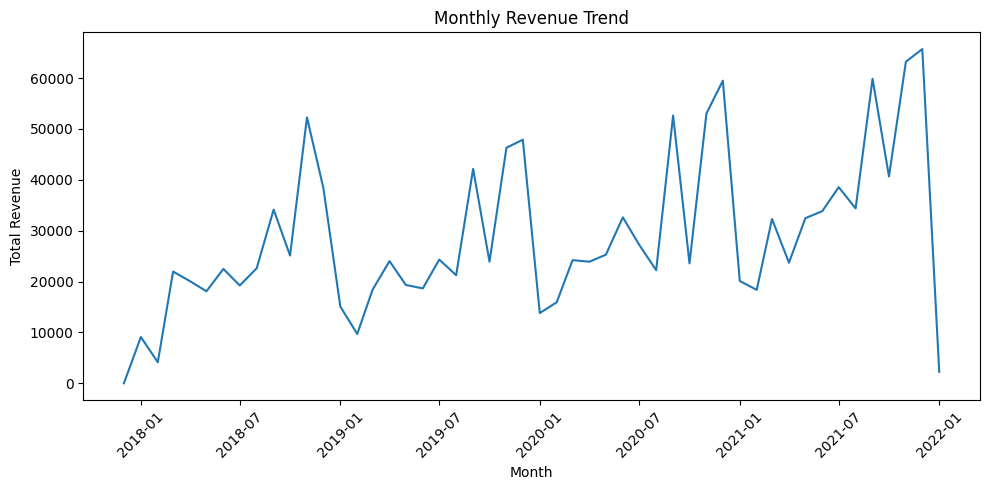

In [ ]:
monthly_revenue = (
    df
    .groupby(df["dispatch_ts"].dt.to_period("M"))["total_sum"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.to_timestamp()


plt.figure(figsize=(10,5))
plt.plot(monthly_revenue)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



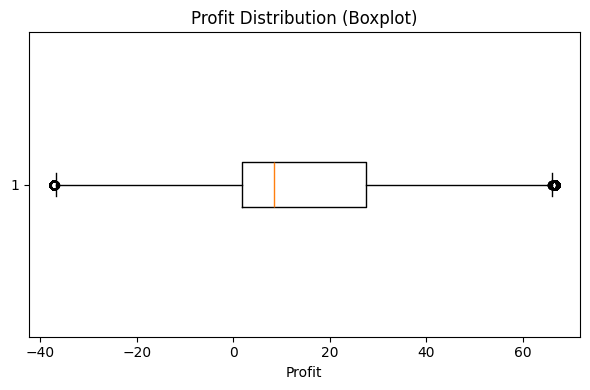

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["profit"], vert=False)
plt.xlabel("Profit")
plt.title("Profit Distribution (Boxplot)")
plt.tight_layout()
plt.show()


In [ ]:
cl.columns


Index(['client_id', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.columns


Index(['transaction_id', 'zip_code', 'country_code', 'state_name', 'city_name',
       'delivery_type', 'sales_zone', 'client_segment', 'client_id',
       'order_ts', 'dispatch_ts', 'item_id', 'item_description', 'units_count',
       'total_sum', 'profit', 'discount'],
      dtype='object')

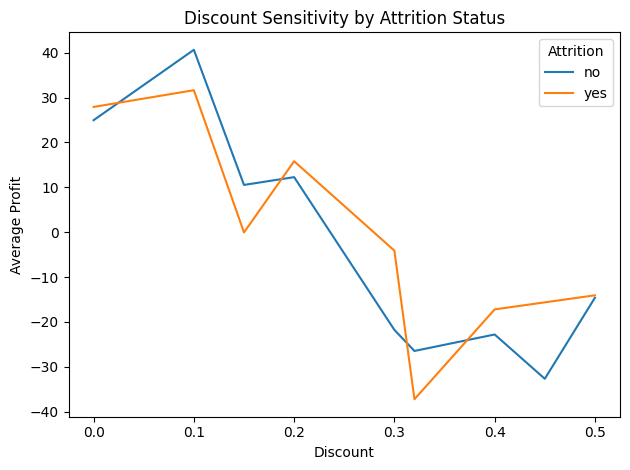

In [ ]:
attr_disc = (
    merged
    .groupby(["Attrition", "discount"])["profit"]
    .mean()
    .reset_index()
)

for a in attr_disc["Attrition"].unique():
    subset = attr_disc[attr_disc["Attrition"] == a]
    plt.plot(subset["discount"], subset["profit"], label=a)

plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.title("Discount Sensitivity by Attrition Status")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()


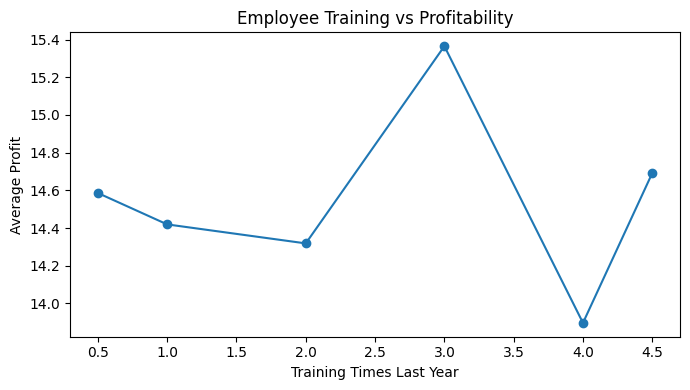

In [ ]:
training_profit = (
    merged
    .groupby("TrainingTimesLastYear")["profit"]
    .mean()
)

training_profit.plot(marker="o", figsize=(7,4))
plt.xlabel("Training Times Last Year")
plt.ylabel("Average Profit")
plt.title("Employee Training vs Profitability")
plt.tight_layout()
plt.show()


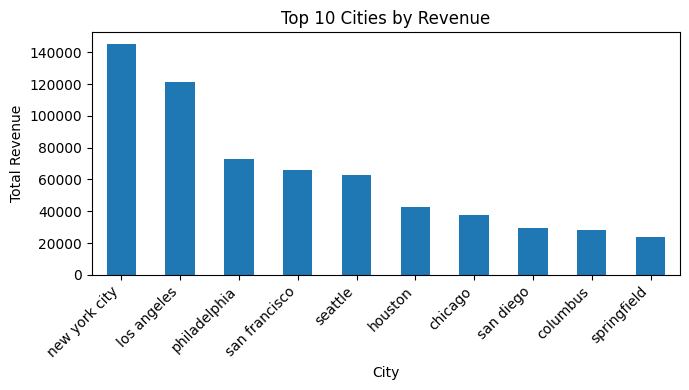

In [ ]:
top_cities = (
    df
    .groupby("city_name")["total_sum"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(7,4))
top_cities.plot(kind="bar")
plt.ylabel("Total Revenue")
plt.xlabel("City")
plt.title("Top 10 Cities by Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Time Series Analysis and Forecasting

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima.fit(disp=False)

pred_test_sarima = sarima_fit.forecast(steps=12)

rmse_s = np.sqrt(mean_squared_error(test, pred_test_sarima))
mae_s  = mean_absolute_error(test, pred_test_sarima)

print("SARIMA RMSE:", rmse_s)
print("SARIMA MAE :", mae_s)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA RMSE: 8918.580996654344
SARIMA MAE : 6558.4569237407


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


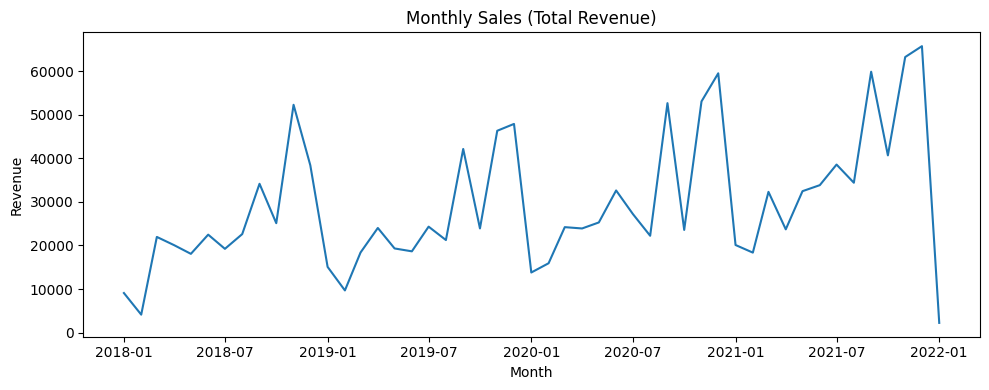


ADF Test: Monthly Sales
ADF Statistic: 0.8208489298236381
p-value: 0.9919653627971186
Result: Non-stationary (fail to reject H0)

ADF Test: Monthly Sales (1st Difference)
ADF Statistic: -14.044587489981513
p-value: 3.257862366910342e-26
Result: Stationary (reject H0)


<Figure size 1000x400 with 0 Axes>

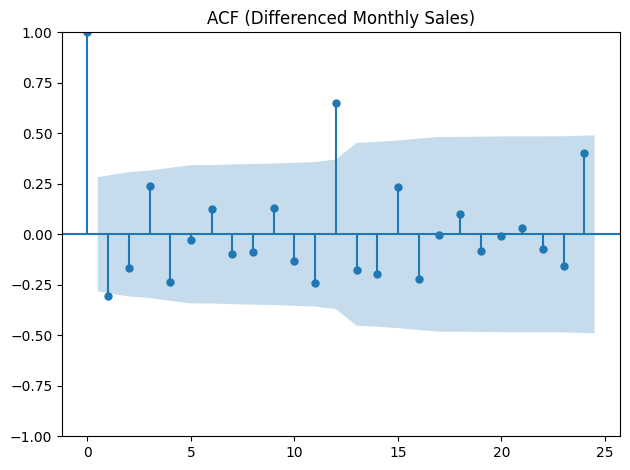

<Figure size 1000x400 with 0 Axes>

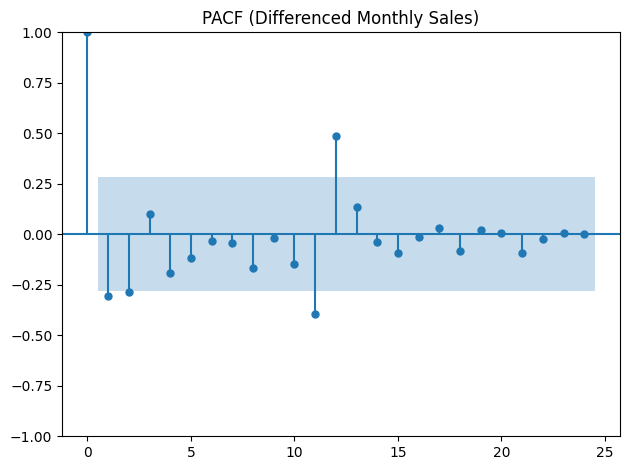

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                          total_sum   No. Observations:                   37
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -99.340
Date:                            Wed, 24 Dec 2025   AIC                            208.679
Time:                                    21:28:36   BIC                            210.192
Sample:                                01-01-2018   HQIC                           207.020
                                     - 01-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2463      1.064     -0.231      0.817      -2.332       1.839
ma.L1         -0.9759      0.738   

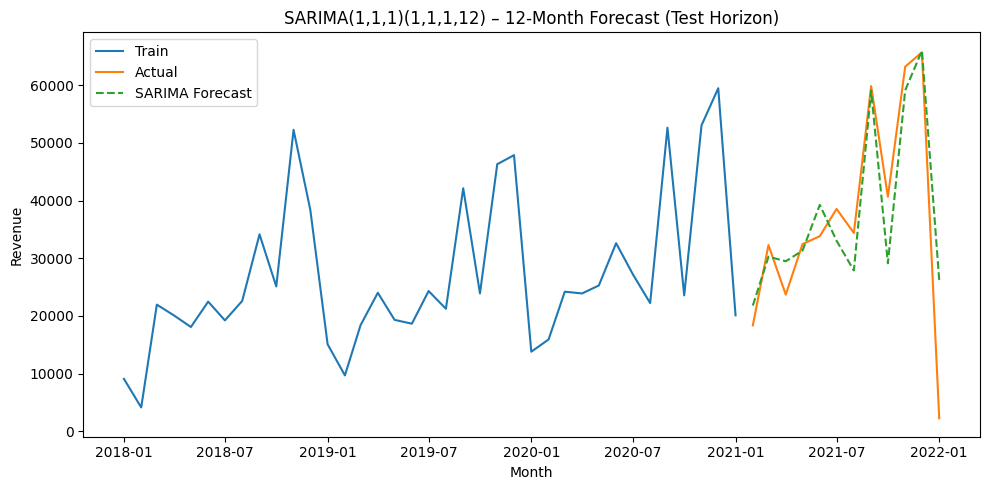


Forecast accuracy on last 12 months:
RMSE: 8540.129785371997
MAE : 5868.52428730966


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


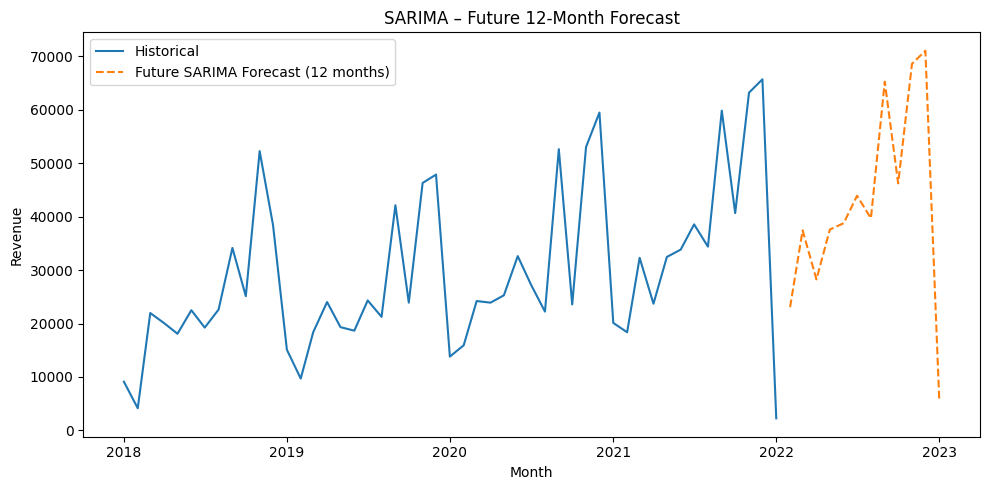


Future 12-month forecast:
2022-02-01    23070.926997
2022-03-01    37436.185634
2022-04-01    28258.297935
2022-05-01    37585.186100
2022-06-01    38774.196082
2022-07-01    43913.008137
2022-08-01    39691.103262
2022-09-01    65248.629720
2022-10-01    46236.422015
2022-11-01    68604.267951
2022-12-01    71057.520541
2023-01-01     5729.371214
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
# ===== SARIMA TIME SERIES PIPELINE (MONTHLY) =====
# Required steps covered:
# 1) Aggregate to monthly frequency
# 2) ADF stationarity test (+ prints stationary / non-stationary)
# 3) Plot ACF & PACF
# 4) Fit SARIMA model
# 5) Forecast next 12 periods
# 6) Evaluate RMSE & MAE (holdout last 12 months)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------- 1) AGGREGATE (MONTHLY) ----------
df["dispatch_ts"] = pd.to_datetime(df["dispatch_ts"], errors="coerce")

# (optional) filter obvious wrong years if needed
df = df[df["dispatch_ts"].dt.year.between(2018, 2025)]

monthly_sales = (
    df.groupby(df["dispatch_ts"].dt.to_period("M"))["total_sum"]
      .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.asfreq("MS")   # Month Start frequency
monthly_sales = monthly_sales.fillna(0)      # fill missing months, if any

# quick plot
plt.figure(figsize=(10,4))
plt.plot(monthly_sales)
plt.title("Monthly Sales (Total Revenue)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


# ---------- 2) ADF TEST + STATIONARY / NON-STATIONARY ----------
def adf_report(series, name="Series"):
    res = adfuller(series.dropna())
    print(f"\nADF Test: {name}")
    print("ADF Statistic:", res[0])
    print("p-value:", res[1])
    if res[1] < 0.05:
        print("Result: Stationary (reject H0)")
    else:
        print("Result: Non-stationary (fail to reject H0)")
    return res

adf_report(monthly_sales, "Monthly Sales")

# Differenced series for ACF/PACF visuals (common when original is non-stationary)
monthly_sales_diff = monthly_sales.diff().dropna()
adf_report(monthly_sales_diff, "Monthly Sales (1st Difference)")


# ---------- 3) ACF / PACF ----------
plt.figure(figsize=(10,4))
plot_acf(monthly_sales_diff, lags=24)
plt.title("ACF (Differenced Monthly Sales)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(monthly_sales_diff, lags=24)
plt.title("PACF (Differenced Monthly Sales)")
plt.tight_layout()
plt.show()


# ---------- 4) FIT SARIMA ----------
# Holdout last 12 months for evaluation
train = monthly_sales.iloc[:-12]
test  = monthly_sales.iloc[-12:]

# A reasonable baseline seasonal model for monthly data (season length = 12)
# order=(p,d,q), seasonal_order=(P,D,Q,12)
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())


# ---------- 5) FORECAST NEXT 12 PERIODS (TEST HORIZON) ----------
pred_test = sarima_fit.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, pred_test, label="SARIMA Forecast", linestyle="--")
plt.title("SARIMA(1,1,1)(1,1,1,12) – 12-Month Forecast (Test Horizon)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


# ---------- 6) EVALUATE (RMSE & MAE) ----------
rmse = np.sqrt(mean_squared_error(test, pred_test))
mae  = mean_absolute_error(test, pred_test)

print("\nForecast accuracy on last 12 months:")
print("RMSE:", rmse)
print("MAE :", mae)


# ---------- FINAL: FIT ON FULL SERIES + FUTURE 12 MONTHS ----------
final_sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_12 = final_sarima.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales, label="Historical")
plt.plot(future_12.index, future_12, label="Future SARIMA Forecast (12 months)", linestyle="--")
plt.title("SARIMA – Future 12-Month Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

print("\nFuture 12-month forecast:")
print(future_12)


# Unsupervised Learning: Customer Segmentation

In [ ]:
cust_tx = (
    df
    .groupby("client_id")
    .agg(
        total_revenue=("total_sum", "sum"),
        total_profit=("profit", "sum"),
        avg_discount=("discount", "mean"),
        total_units=("units_count", "sum"),
        num_orders=("transaction_id", "count")
    )
    .reset_index()
)


In [ ]:
cust = cl.merge(cust_tx, on="client_id", how="left")
cust = cust.fillna(0)


In [ ]:
num_features = [
    "Age",
    "MonthlyIncome",
    "total_revenue",
    "total_profit",
    "avg_discount",
    "num_orders"
]

cat_features = [
    "Gender",
    "Department",
    "JobRole",
    "MaritalStatus"
]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

X = preprocessor.fit_transform(cust)


In [ ]:
from sklearn.cluster import KMeans
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)


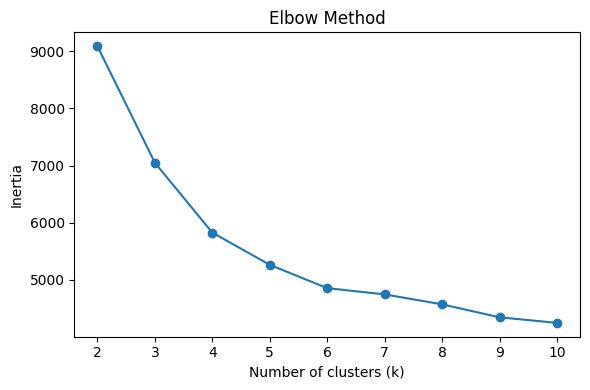

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))


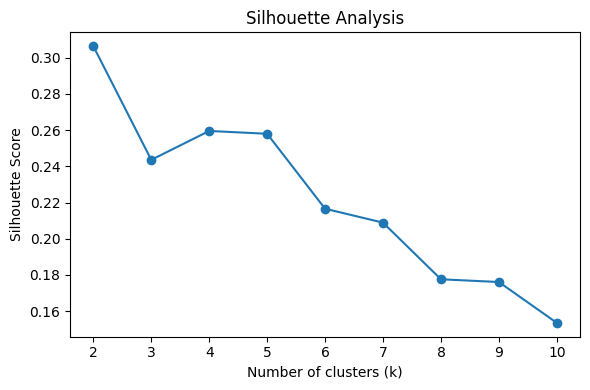

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.tight_layout()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cust["cluster"] = kmeans.fit_predict(X)



In [ ]:
cluster_profile = (
    cust
    .groupby("cluster")[num_features]
    .mean()
    .round(2)
)

cluster_profile


,Age,MonthlyIncome,total_revenue,total_profit,avg_discount,num_orders
cluster,,,,,,
0,34.90,3895.08,432.27,58.58,0.08,3.92
1,45.93,11969.06,1886.36,138.08,0.15,11.05
2,30.50,2798.24,5244.64,622.39,0.13,23.05
3,36.88,6273.52,378.09,43.90,0.23,6.47


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

# если X sparse — переводим в dense для PCA
X_pca_input = X.toarray() if sp.issparse(X) else X

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_input)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.34491807 0.20699812]


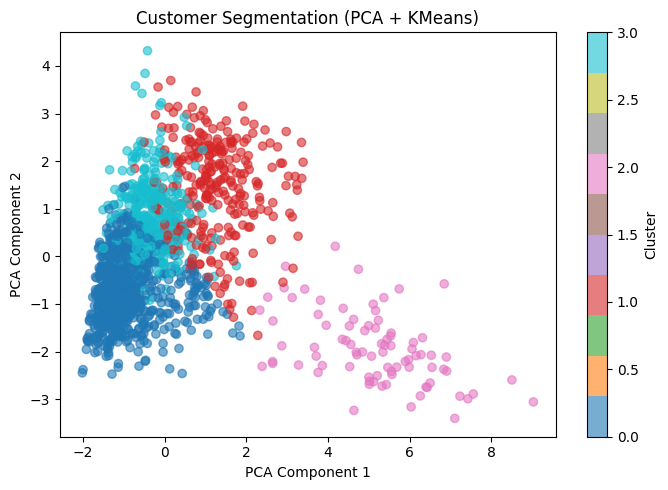

In [ ]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cust["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation (PCA + KMeans)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

best_k = K[silhouette.index(max(silhouette))]
print("Best k based on silhouette score:", best_k)



Best k based on silhouette score: 2


In [ ]:
silhouette_scores = []

K = range(2, 12)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Таблица
sil_df = pd.DataFrame({
    "k": list(K),
    "silhouette_score": silhouette_scores
})

print(sil_df)


    k  silhouette_score
0   2          0.306412
1   3          0.243591
2   4          0.259562
3   5          0.258000
4   6          0.216581
5   7          0.208889
6   8          0.177595
7   9          0.176084
8  10          0.153501
9  11          0.160129


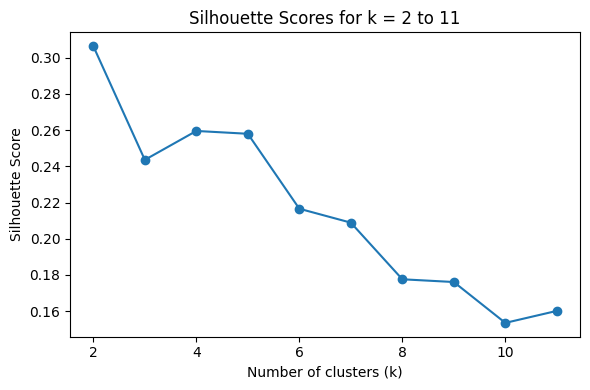

In [ ]:
# График
plt.figure(figsize=(6,4))
plt.plot(sil_df["k"], sil_df["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for k = 2 to 11")
plt.tight_layout()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
cust["cluster"] = kmeans.fit_predict(X)


In [ ]:
cluster_profile = (
    cust
    .groupby("cluster")[num_features]
    .mean()
    .round(2)
)

cluster_profile

,Age,MonthlyIncome,total_revenue,total_profit,avg_discount,num_orders
cluster,,,,,,
0,35.73,4822.13,417.74,50.76,0.13,4.65
1,42.09,9554.46,2769.70,269.75,0.15,14.47


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

# если X sparse — переводим в dense для PCA
X_pca_input = X.toarray() if sp.issparse(X) else X

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_input)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.34491807 0.20699812]


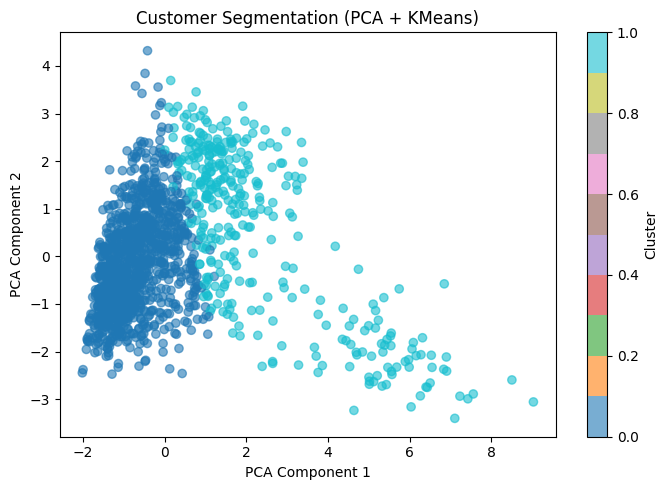

In [ ]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cust["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation (PCA + KMeans)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


#  Predictive Modeling: Customer Purchase Propensity

In [ ]:
# выберем самый частый item_description как "product category"
target_item = df["item_description"].value_counts().index[0]
print("Target category/item:", target_item)


Target category/item: office supplies_envelopes_staples


In [ ]:
target_df = (
    df.assign(target_purchase=(df["item_description"] == target_item).astype(int))
      .groupby("client_id")["target_purchase"]
      .max()
      .reset_index()
)
target_df.head()


,client_id,target_purchase
0,c0000,0
1,c0001,0
2,c0002,0
3,c0003,0
4,c0004,0


In [ ]:
tx_features = (
    df.groupby("client_id")
      .agg(
          num_orders=("transaction_id", "count"),
          total_revenue=("total_sum", "sum"),
          total_profit=("profit", "sum"),
          avg_order_value=("total_sum", "mean"),
          avg_discount=("discount", "mean"),
          total_units=("units_count", "sum"),
          unique_items=("item_id", "nunique"),
      )
      .reset_index()
)
tx_features.head()


,client_id,num_orders,total_revenue,total_profit,avg_order_value,avg_discount,total_units,unique_items
0,c0000,6,105.09000,50.161500,17.515000,0.283333,20.0,6
1,c0001,7,1294.61633,170.015807,184.945190,0.085714,24.0,7
2,c0002,2,88.58400,24.495200,44.292000,0.100000,8.0,2
3,c0003,4,342.34400,-34.284237,85.586000,0.150000,7.0,4
4,c0004,3,231.30800,78.524400,77.102667,0.066667,8.0,3


In [ ]:
data = (cl.merge(tx_features, on="client_id", how="left")
          .merge(target_df, on="client_id", how="left"))

# если у клиента нет транзакций → заполним 0
for col in ["num_orders","total_revenue","total_profit","avg_order_value",
            "avg_discount","total_units","unique_items"]:
    data[col] = data[col].fillna(0)

# если клиент не покупал целевой товар → 0
data["target_purchase"] = data["target_purchase"].fillna(0).astype(int)

data.shape, data["target_purchase"].value_counts()


((1472, 44),
 target_purchase
 0    1431
 1      41
 Name: count, dtype: int64)

In [ ]:
X = data.drop(columns=["target_purchase"])
y = data["target_purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1177, 43) Test: (295, 43)


In [ ]:
num_features = [
    "Age", "MonthlyIncome",
    "num_orders", "total_revenue", "total_profit",
    "avg_order_value", "avg_discount", "total_units", "unique_items"
]

cat_features = [
    "Gender", "Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime"
]

# оставляем только те, что реально есть
num_features = [c for c in num_features if c in X.columns]
cat_features = [c for c in cat_features if c in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


****LogisticRegression****

In [ ]:
model = LogisticRegression(max_iter=2000)

clf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", model)
])

clf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'MonthlyIncome',
                                                   'num_orders',
                                                   'total_revenue',
                                                   'total_profit',
                                                   'avg_order_value',
                                                   'avg_discount',
                                                   'total_units',
                                                   'unique_items']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Department',
                                                   'JobRole', 'MaritalStatus',
                                                   'BusinessTravel',
                                                   'OverTime'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [ ]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_proba)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", roc)

print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.9661016949152542
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.9594947735191637

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       287
           1       0.00      0.00      0.00         8

    accuracy                           0.97       295
   macro avg       0.49      0.50      0.49       295
weighted avg       0.95      0.97      0.96       295



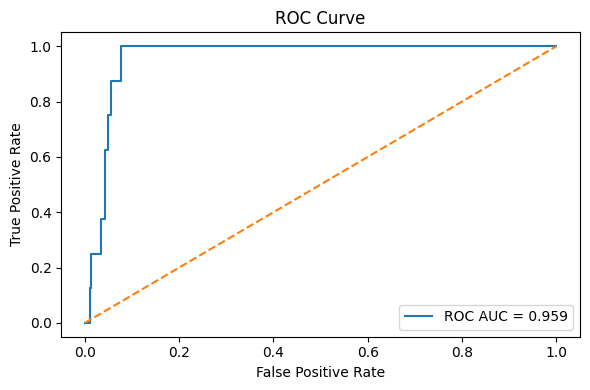

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


**RandomForestClassifier, DecisionTreeClassifier,Gradient Boosting Classifier**

In [ ]:
def evaluate_model(model, name):
    clf = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

    return clf


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

dt_clf = evaluate_model(dt_model, "Decision Tree")



Decision Tree
Accuracy : 0.9288135593220339
Precision: 0.19047619047619047
Recall   : 0.5
F1-score : 0.27586206896551724
ROC-AUC  : 0.7203832752613242


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_clf = evaluate_model(rf_model, "Random Forest")




Random Forest
Accuracy : 0.9694915254237289
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.9412020905923344


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_clf = evaluate_model(gb_model, "Gradient Boosting")



Gradient Boosting
Accuracy : 0.9661016949152542
Precision: 0.25
Recall   : 0.125
F1-score : 0.16666666666666666
ROC-AUC  : 0.9472996515679443


In [ ]:
results = []

for name, model in [
    ("Decision Tree", dt_model),
    ("Random Forest", rf_model),
    ("Gradient Boosting", gb_model),
]:
    clf = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.928814,0.190476,0.500,0.275862,0.720383
1,Random Forest,0.969492,0.000000,0.000,0.000000,0.941202
2,Gradient Boosting,0.966102,0.250000,0.125,0.166667,0.947300


# FINAL

1. Customer behavior and sales patterns

The data shows clear patterns in customer behavior and sales.
Most customers make small purchases, while a small number of customers generate most of the revenue and profit.
This means that the business depends strongly on high-value customers.

Monthly sales change over time. Some months have higher sales than others.
This shows seasonality and changes in customer demand.
Revenue can grow, but profit does not always grow at the same time.
High sales can have low profit because of discounts and promotions.

Discounts have a strong negative effect on profit.
When discounts are high, profit is often low or even negative.

2.Customer characteristics and product interest

Customer segmentation shows that customers are not all the same.
Some customers buy often and spend more money.
Other customers buy less and use many discounts.

Classification models show that past customer behavior is the most important factor.
Customers with many past purchases and high total spending are more likely to be interested in a product.
Customer income and job-related characteristics also influence product interest, but less than purchase history.

This means that transaction data is more useful than only demographic data.

3.The forecasting models show acceptable accuracy.
SARIMA works better than ARIMA because it considers seasonality.
These models are useful for planning future sales, but they are not perfectly accurate.

The classification models show good performance.
Random Forest and Gradient Boosting give the best results.
ROC-AUC values show that the models can separate interested and not interested customers better than random guessing.

Overall, the models are reliable enough for business decisions.

4. Business recommendations

Based on the analysis, the following actions are recommended:

Targeted marketing
Focus marketing campaigns on customers with high predicted interest and high value.

Discount control
Do not give large discounts to all customers.
Use discounts only for selected customer groups.

Customer retention
Keep high-value customers with loyalty programs and special offers.

Demand forecasting
Use monthly sales forecasts to plan inventory and staffing.

Data-driven decisions
Update models regularly and use data to support business strategy

5. Conclusion

The analysis shows that customer behavior and past purchases are key drivers of sales and profit.
Using segmentation, forecasting, and classification helps the business understand customers better.
These methods support better marketing, pricing, and planning decisions.